In [1]:
import os
import shutil
if os.path.isdir("/Library/TeX/texbin"):                         # TeX Live on macOS
    os.environ["PATH"] = "/Library/TeX/texbin:" + os.environ["PATH"]

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter
from matplotlib import rcParams
from math import sqrt, pi
from scipy.integrate import quad

rcParams.update({
    "text.usetex": shutil.which("latex") is not None,  # Use LaTeX for text (mathtext if LaTeX is not installed)
    "font.family": "serif",            # Use serif fonts
    "font.serif": ["Computer Modern"], # Default LaTeX font
    "axes.labelsize": 14,              # Axis label size
    "font.size": 13,                   # General font size
    "legend.fontsize": 12,             # Legend font size
    "xtick.labelsize": 12,             # X tick label size
    "ytick.labelsize": 12,             # Y tick label size
    "text.latex.preamble": r"\usepackage{amsmath,amssymb}"  # Optional packages
})

from scipy.special import gamma, gammainc
from scipy.integrate import quad
from scipy.special import hyp2f1

In [3]:
def langevin(a):
    a = np.asarray(a)
    out = np.empty_like(a, dtype=float)
    small = np.abs(a) < 1e-3

    # small-a expansion: L(a) ~ a/3 - a^3/45 + ...
    out[small] = a[small] / 3.0 * (1.0 - a[small]**2/15.0)

    # general case: L(a) = coth(a) - 1/a
    aa = a[~small]
    out[~small] = 1.0/np.tanh(aa) - 1.0/aa
    return out

In [4]:
def L_over_a(a):
    a = np.asarray(a)
    small = np.abs(a) < 1e-3
    out = np.empty_like(a, dtype=float)

    # For small a, L(a)/a -> 1/3 - a^2/45 + ...
    out[small] = 1.0/3.0 * (1.0 - a[small]**2/15.0)

    aa = a[~small]
    out[~small] = langevin(aa) / aa
    return out

In [5]:
def J_vs_sigma(v_star, sigma):
    prefac = 1.0 / (sqrt(2.0*pi) * sigma * v_star)

    def integrand(u):
        a = u * v_star / sigma**2
        gauss_part = np.exp(-(u - v_star)**2 / (2.0 * sigma**2)) \
                   - np.exp(-(u + v_star)**2 / (2.0 * sigma**2))
        return gauss_part * L_over_a(a)

    # Truncate at some finite upper limit where the Gaussians are tiny
    u_max = v_star + 6.0 * sigma
    val, err = quad(integrand, 0.0, u_max, epsabs=1e-8, epsrel=1e-6)
    return prefac * val

In [6]:
def S_mass(M, mass_cut):
    """
    Suppression factor:
        S(M) = (1 + mass_cut / M)^(-1)
    """
    return 1.0 / (1.0 + mass_cut / M)


def dNdM(M, M0, alpha, A):
    """
    Mass function:
        dN/dM = A * (M / M0)^(-alpha)
    """
    return A * (M / M0)**(-alpha)


def B_of_M_approx(M, B0):
    """
    Approximate B(M) using:
        B(M) ≈ B0 - ln(M)
    where B0 is treated as a constant parameter.
    """
    return B0 - np.log(M)


def mass_integrand(M, M0, alpha, A, B0, mass_cut):
    """
    Integrand for the mass part of D_II:
        integrand = (dN/dM) * M^2 * B(M) * S(M)
    with:
        dN/dM = A * (M / M0)^(-alpha)
        B(M) ≈ B0 - ln(M)
        S(M) = (1 + mass_cut / M)^(-1)
    """
    return dNdM(M, M0, alpha, A) * M**2 * B_of_M_approx(M, B0) * S_mass(M, mass_cut)


def mass_integral_quad(M_min, M_max, M0, alpha, A, B0, mass_cut):
    """
    Numerically evaluate:
        I = ∫_{M_min}^{M_max} dM (dN/dM) M^2 B(M) S(M)
    using scipy.integrate.quad.
    """
    I, err = quad(
        mass_integrand,
        M_min,
        M_max,
        args=(M0, alpha, A, B0, mass_cut),
        epsabs=0,
        epsrel=1e-5,
        limit=200
    )
    return I  # you can also return (I, err) if you care about the error

In [7]:
# Constants & fiducial parameters
G = 4.302e-6  # kpc (km/s)^2 / Msun
sigma = 200   # km/s, subhalo velocity dispersion (typical)
V0 = 230      # km/s, characteristic circular speed

alpha  = 1.9
M0     = 2.52e7
A      = 3.26e-5

In [8]:
# --- Aquarius Einasto parameters ---
alpha_E = 0.678
r200 = 210.0       # kpc
r_minus2 = 0.81 * r200

# --- Normalization constant ---
x200 = (2.0 / alpha_E) * (r200 / r_minus2)**alpha_E
s = 3.0 / alpha_E
N = (4 * np.pi * r_minus2**3 * np.exp(2/alpha_E)
     * (alpha_E/2)**(3/alpha_E) / alpha_E
     * gamma(s) * gammainc(s, x200))

def P(r):
    """Normalized Aquarius Einasto number-density profile (1/kpc^3)."""
    rho = np.exp(- (2/alpha_E) * ((r / r_minus2)**alpha_E - 1.0))
    return rho / N

In [9]:
def mass_integral(M_min, M_max, M_cut, alpha):
    """
    Computes ∫ M^(3-α)/(M + M_cut) dM from M_min to M_max,
    handling the M_cut=0 case explicitly.
    """
    # Special case: pure power-law (no cutoff)
    if M_cut == 0:
        if np.isclose(alpha, 3.0):
            return np.log(M_max / M_min)
        else:
            return (M_max**(3 - alpha) - M_min**(3 - alpha)) / (3 - alpha)
    
    # General case: M_cut > 0
    if np.isclose(alpha, 4.0):
        return (1/M_cut) * np.log((M_max*(M_min + M_cut)) / (M_min*(M_max + M_cut)))

    prefactor = 1.0 / (4.0 - alpha)
    term_max = M_max**(4 - alpha) * hyp2f1(1, 4 - alpha, 5 - alpha, -M_max / M_cut)
    term_min = M_min**(4 - alpha) * hyp2f1(1, 4 - alpha, 5 - alpha, -M_min / M_cut)
    return prefactor * (term_max - term_min)

In [10]:
def resonance_action(m_resonance, n_resonance, pattern_speed, radius_bar, strength_bar):

    n       = n_resonance
    m       = m_resonance
    omega_p = pattern_speed
    R_bar   = radius_bar
    f_bar   = strength_bar

    # For a flat rotation curve, the resonance radius is given by
    R_res = (V0 / omega_p)*(1 + (n/m)*np.sqrt(2))   # kpc

    # For a flat rotation curve in an axisymmetric potential, one finds approximately
    # alpha = dOmega_phi/dLz ~ 1/R^2.
    alpha = m*np.abs(m+n*np.sqrt(2)) / R_res**2
    
    # And we set the effective bar strength parameter epsilon to be:
    #epsilon = f_bar * V0**2 * (R_res**2) / (R_res + R_bar)**5 # (km/s)^2
    epsilon = f_bar * ((R_res + R_bar)**5/(R_res**2)) * (V0**2)/2 * (R_res**2) / (R_res + R_bar)**5 # (km/s)^2

    # Then the resonance (pendulum) full width in the action is:
    Delta_I_half = 4 * np.sqrt(epsilon / alpha)

    return Delta_I_half

In [11]:
def diffusion_coefficient(m_resonance, n_resonance, pattern_speed, mass_min, mass_max, mass_cut, impact_max, type, f_sup):
    results = []
    for mass_max_i in np.atleast_1d(mass_max):
        b_max   = impact_max
        n       = n_resonance
        m       = m_resonance
        omega_p = pattern_speed

        # b-min
        m_min = 10**mass_min  # M_sun
        m_max = 10**mass_max_i  # M_sun

        # B term
        if type == 'P':
            #mass_int = mass_integral(m_min, m_max, M0, alpha, A, B0=27.15)
            mass_int = mass_integral_quad(m_min, m_max, M0, alpha, A, B0=27.15, mass_cut=10**mass_cut)
        if type == 'H':
            #mass_int = mass_integral(m_min, m_max, M0, alpha, A, B0=28.02)
            mass_int = mass_integral_quad(m_min, m_max, M0, alpha, A, B0=28.02, mass_cut=10**mass_cut)

        R_res = (V0 / omega_p)*(1 + (n/m)*np.sqrt(2))   # kpc
        P_res = f_sup*P(R_res)

        # Pre-factor
        prefactor = 2*np.pi * G**2 * (R_res/m)**2

        D = prefactor*mass_int*P_res*J_vs_sigma(V0, sigma)
        results.append(D)

    return np.array(results)


def diffusion_timescale(m_resonance, n_resonance, pattern_speed, radius_bar, strength_bar, mass_min, mass_max, mass_cut, impact_max, type, f_sup):

    n       = n_resonance
    m       = m_resonance
    omega_p = pattern_speed
    R_bar   = radius_bar
    f_bar   = strength_bar

    # For a flat rotation curve, the resonance radius is given by
    R_res = (V0 / omega_p)*(1 + (n/m)*np.sqrt(2))   # kpc

    # For a flat rotation curve in an axisymmetric potential, one finds approximately
    # alpha = dOmega_phi/dLz ~ 1/R^2.
    alpha = m*np.abs(m+n*np.sqrt(2)) / R_res**2
    
    # And we set the effective bar strength parameter epsilon to be:
    #epsilon = f_bar * V0**2 * (R_res**2) / (R_res + R_bar)**5 # (km/s)^2
    epsilon = f_bar * ((R_res + R_bar)**5/(R_res**2)) * (V0**2)/2 * (R_res**2) / (R_res + R_bar)**5 # (km/s)^2

    # Then the resonance (pendulum) full width in the action is:
    Delta_I_half = 2 * np.sqrt(4*epsilon / alpha)

    t_diff = (Delta_I_half)**2 / (2*diffusion_coefficient(m_resonance, n_resonance, pattern_speed, mass_min, mass_max, mass_cut, impact_max, type, f_sup))
    t_lib  = (2*np.pi)/np.sqrt(alpha*epsilon)

    #print(f't_diff = {t_diff}')

    return [t_diff, (4/np.pi)*(t_lib/t_diff)]

    

In [12]:
M = np.linspace(5,10, 100)

D_list_cdm     = diffusion_coefficient(m_resonance=2, n_resonance=0, pattern_speed = 40, mass_min=3, mass_max=M, mass_cut=0, impact_max=200, type='P', f_sup=1)
delta_list_cdm = diffusion_timescale(m_resonance=2, n_resonance=0, pattern_speed = 40, radius_bar=1.6, strength_bar=0.02, mass_min=3, mass_max=M, mass_cut=0, impact_max=200, type='P', f_sup=1)

D_list_cdm_f1     = diffusion_coefficient(m_resonance=2, n_resonance=0, pattern_speed = 40, mass_min=3, mass_max=M, mass_cut=0, impact_max=200, type='P', f_sup=1/3)
delta_list_cdm_f1 = diffusion_timescale(m_resonance=2, n_resonance=0, pattern_speed = 40, radius_bar=1.6, strength_bar=0.02, mass_min=3, mass_max=M, mass_cut=0, impact_max=200, type='P', f_sup=1/3)

D_list_cdm_f2     = diffusion_coefficient(m_resonance=2, n_resonance=0, pattern_speed = 40, mass_min=3, mass_max=M, mass_cut=0, impact_max=200, type='P', f_sup=1/6)
delta_list_cdm_f2 = diffusion_timescale(m_resonance=2, n_resonance=0, pattern_speed = 40, radius_bar=1.6, strength_bar=0.02, mass_min=3, mass_max=M, mass_cut=0, impact_max=200,type='P', f_sup=1/6)

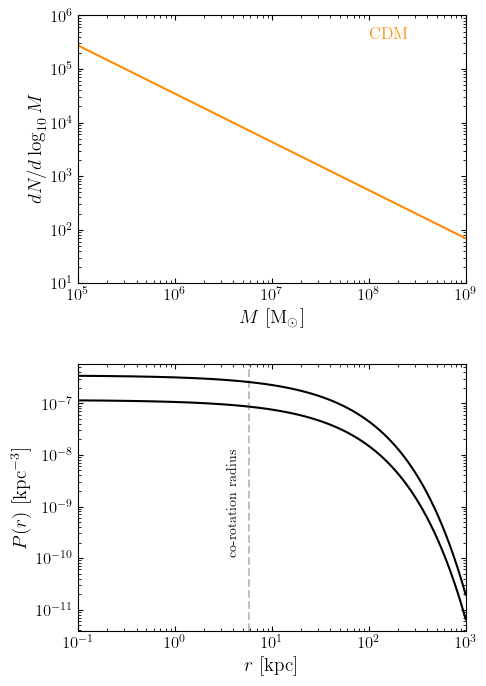

In [13]:
fig, (ax1, ax2) = plt.subplots(
    2, 1, figsize=(5, 8),
    gridspec_kw={'hspace': 0.3}  # directly set spacing here
)

for axis in (ax1, ax2):
    axis.set_rasterization_zorder(10)
    axis.set_xscale('log')
    axis.set_yscale('log')
    axis.tick_params(axis='both', which='both',
                   direction='in', top=True, right=True)

M = np.logspace(5,9,100)
dndm = A*(M/M0)**(-alpha)
ax1.plot(M, np.log(10)*M*dndm, color='darkorange')
ax1.set_xlabel(r'$M$ [M$_{\odot}$]')
ax1.set_ylabel(r'$dN / d \log_{10} M$')

r = np.logspace(-1,3,100)
ax2.plot(r, P(r), color='k')
ax2.plot(r, (1/3)*P(r), color='k')
ax2.set_xlabel('$r$ [kpc]')
ax2.set_ylabel('$P(r)$ [kpc$^{-3}$]')

ax2.axvline(V0/40, color='k', linestyle='--', alpha=0.25)
ax2.text(
    10**0.6, 1e-10,                        
    'co-rotation radius',       # text
    ha='center', va='bottom',        
    fontsize=10, color='k',           
    rotation='vertical'
)

ax1.text(
    0.8, 0.9,                        
    r'CDM',
    transform=ax1.transAxes,
    ha='center', va='bottom',        
    fontsize=12, color='darkorange',           
)

ax1.set_xlim(10**5, 10**9)
ax1.set_ylim(10, 10**6)
ax2.set_xlim(10**-1, 10**3)

#plt.savefig('../figures/dark_matter_properties.pdf', dpi=400, bbox_inches='tight')
plt.show()

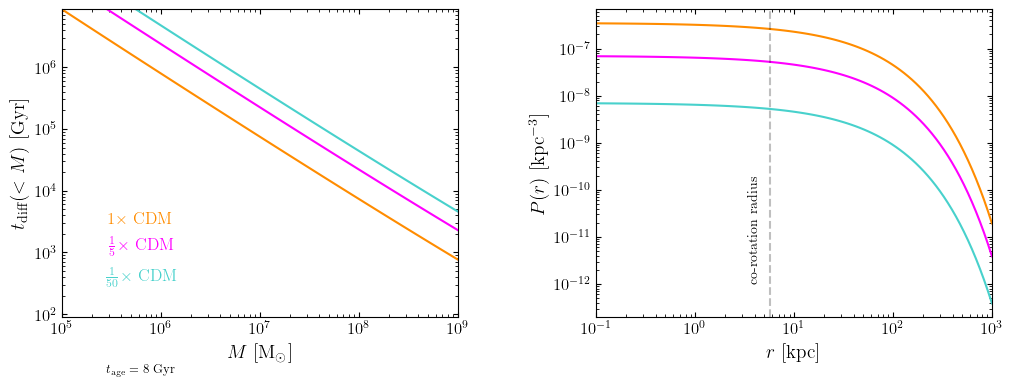

In [14]:
fig, (ax1, ax2) = plt.subplots(
    1, 2, figsize=(12, 4),
    gridspec_kw={'wspace': 0.35}  # directly set spacing here
)

for axis in (ax1, ax2):
    axis.set_rasterization_zorder(10)
    axis.set_xscale('log')
    axis.set_yscale('log')
    axis.tick_params(axis='both', which='both',
                   direction='in', top=True, right=True)
ax1.set_xlim(1e5,1e9)
ax2.set_xlim(10**-1, 10**3)
ax1.set_xlabel(r'$M$ [M$_{\odot}$]')

M = np.linspace(5,10, 100)

ax1.plot(10**M, delta_list_cdm[0], color='darkorange')
ax1.plot(10**M, delta_list_cdm_f1[0], color='magenta')
ax1.plot(10**M, delta_list_cdm_f2[0], color='mediumturquoise')
ax1.set_ylim(min(delta_list_cdm[0]), max(delta_list_cdm[0]))

ax1.set_ylabel(r'$t_{\rm diff}(<M)$ [Gyr]')

ax1.axhline(8.0, linestyle='--', c='k')
#ax1.axvline(10**8, alpha=0.1, c='k')
ax1.text(
    10**5.8, 10,                       
    #'upper limit for bar age',   
    r'$t_{\rm age} = 8$ Gyr',
    ha='center', va='bottom',        
    fontsize=9, color='k'           
)

ax1.text(
    0.2, 0.3,                        
    r'$1 \times$ CDM',
    transform=ax1.transAxes,
    ha='center', va='bottom',        
    fontsize=12, color='darkorange',           
)
ax1.text(
    0.2, 0.2,                        
    r'$\frac{1}{5} \times$ CDM',
    transform=ax1.transAxes,
    ha='center', va='bottom',        
    fontsize=12, color='magenta',           
)
ax1.text(
    0.2, 0.1,                        
    r'$\tfrac{1}{50} \times$ CDM',
    transform=ax1.transAxes,
    ha='center', va='bottom',        
    fontsize=12, color='mediumturquoise',           
)

r = np.logspace(-1,3,100)
ax2.plot(r, P(r), color='darkorange')
ax2.plot(r, (1/5)*P(r), color='magenta')
ax2.plot(r, (1/50)*P(r), color='mediumturquoise')
ax2.set_xlabel('$r$ [kpc]')
ax2.set_ylabel('$P(r)$ [kpc$^{-3}$]')

ax2.text(
    10**0.6, 1e-12,                        
    'co-rotation radius',       # text
    ha='center', va='bottom',        
    fontsize=10, color='k',           
    rotation='vertical'
)

ax2.axvline(V0/40, color='k', linestyle='--', alpha=0.25)

#plt.savefig('../figures/suppression_constraints.pdf', dpi=400, bbox_inches='tight')
plt.show()

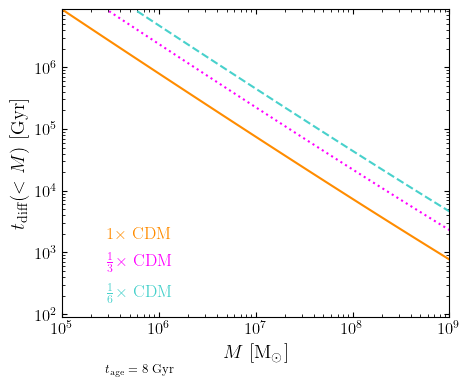

In [15]:
fig, ax1 = plt.subplots(
    1, 1, figsize=(5, 4),
    gridspec_kw={'wspace': 0.35}  # directly set spacing here
)


ax1.set_rasterization_zorder(10)
ax1.set_xscale('log')
ax1.set_yscale('log')
ax1.tick_params(axis='both', which='both',
                direction='in', top=True, right=True)

ax1.set_xlim(1e5,1e9)
ax1.set_xlabel(r'$M$ [M$_{\odot}$]')

M = np.linspace(5,10, 100)

ax1.plot(10**M, delta_list_cdm[0], color='darkorange')
ax1.plot(10**M, delta_list_cdm_f1[0], color='magenta', linestyle=':')
ax1.plot(10**M, delta_list_cdm_f2[0], color='mediumturquoise', linestyle='--')
ax1.set_ylim(min(delta_list_cdm[0]), max(delta_list_cdm[0]))

ax1.set_ylabel(r'$t_{\rm diff}(<M)$ [Gyr]')

ax1.axhline(8.0, linestyle='--', c='k')
#ax1.axvline(10**8, alpha=0.1, c='k')
ax1.text(
    10**5.8, 10,                       
    #'upper limit for bar age',   
    r'$t_{\rm age} = 8$ Gyr',
    ha='center', va='bottom',        
    fontsize=9, color='k'           
)

ax1.text(
    0.2, 0.25,                        
    r'$1 \times$ CDM',
    transform=ax1.transAxes,
    ha='center', va='bottom',        
    fontsize=12, color='darkorange',           
)
ax1.text(
    0.2, 0.15,                        
    r'$\frac{1}{3} \times$ CDM',
    transform=ax1.transAxes,
    ha='center', va='bottom',        
    fontsize=12, color='magenta',           
)
ax1.text(
    0.2, 0.05,                        
    r'$\tfrac{1}{6} \times$ CDM',
    transform=ax1.transAxes,
    ha='center', va='bottom',        
    fontsize=12, color='mediumturquoise',           
)

#plt.savefig('../figures/suppression_constraints.pdf', dpi=400, bbox_inches='tight')
plt.show()